# NLP Project - Women Clothing Reviews Data :

## Importing Necessary Libraries and Packages :

In [1]:
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.decomposition import NMF

from xgboost import XGBClassifier

## 1. Loading Data :

In [2]:
FILE_PATH = r"Womens_Clothing_Reviews_Data.xlsx"
SHEET_NAME = "Woman Clothing Reviews"

df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

## 2. Data Exploration :

In [3]:
print("Shape:", df.shape)

Shape: (23486, 11)


In [4]:
print("\nColumns:\n", df.columns.tolist())


Columns:
 ['Product ID', 'Category', 'Subcategory1', 'SubCategory2', 'Location', 'Channel', 'Customer Age', 'Review Title', 'Review Text', 'Rating', 'Recommend Flag']


In [5]:
print("\nFirst 5 rows:\n", df.head())


First 5 rows:
   Product ID        Category Subcategory1 SubCategory2   Location Channel  \
0         767       Initmates     Intimate    Intimates     Mumbai  Mobile   
1        1080         General      Dresses      Dresses  Bangalore  Mobile   
2        1077         General      Dresses      Dresses    Gurgaon  Mobile   
3        1049  General Petite      Bottoms        Pants    Chennai     Web   
4         847         General         Tops      Blouses  Bangalore     Web   

   Customer Age             Review Title  \
0            33                      NaN   
1            34                      NaN   
2            60  Some major design flaws   
3            50         My favorite buy!   
4            47         Flattering shirt   

                                         Review Text  Rating  Recommend Flag  
0  Absolutely wonderful - silky and sexy and comf...       4               1  
1  Love this dress!  it's sooo pretty.  i happene...       5               1  
2  I had such 

In [6]:
print("\nData types:\n", df.dtypes)


Data types:
 Product ID         int64
Category          object
Subcategory1      object
SubCategory2      object
Location          object
Channel           object
Customer Age       int64
Review Title      object
Review Text       object
Rating             int64
Recommend Flag     int64
dtype: object


In [7]:
print("\nMissing values:\n", df.isna().sum())


Missing values:
 Product ID           0
Category            14
Subcategory1        14
SubCategory2        14
Location             0
Channel              0
Customer Age         0
Review Title      3810
Review Text        845
Rating               0
Recommend Flag       0
dtype: int64


In [8]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 3


In [9]:
print("\nNumerical summary:\n", df.describe(include='all').T)


Numerical summary:
                   count unique  \
Product ID      23486.0    NaN   
Category          23472      3   
Subcategory1      23472      6   
SubCategory2      23472     20   
Location          23486      4   
Channel           23486      2   
Customer Age    23486.0    NaN   
Review Title      19676  13993   
Review Text       22641  22634   
Rating          23486.0    NaN   
Recommend Flag  23486.0    NaN   

                                                              top   freq  \
Product ID                                                    NaN    NaN   
Category                                                  General  13850   
Subcategory1                                                 Tops  10468   
SubCategory2                                              Dresses   6319   
Location                                                  Gurgaon   8821   
Channel                                                       Web  13583   
Customer Age                          

## 3. Basic Data Cleaning :

In [10]:
# Remove exact duplicate rows.
df = df.drop_duplicates().copy()

In [11]:
# Fill categorical missing values.
for col in ['Category', 'Subcategory1', 'SubCategory2']:
    df[col] = df[col].fillna('Unknown')

In [12]:
# Keep missing text rows instead of dropping them.
df['Review Title'] = df['Review Title'].fillna('')
df['Review Text'] = df['Review Text'].fillna('')

In [13]:
# Combine title + review text.
df['Combined Review'] = (
    df['Review Title'].astype(str).str.strip() + ' ' +
    df['Review Text'].astype(str).str.strip()
).str.strip()

In [14]:
# Remove observations with no usable review text at all only for NLP analysis.
df['Has Review Text'] = df['Combined Review'].str.len().gt(0).astype(int)

In [15]:
# Age groups for business analysis.
df['Age Group'] = pd.cut(
    df['Customer Age'],
    bins=[17, 25, 35, 45, 55, 65, np.inf],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
)

In [16]:
print("\nCleaned shape:", df.shape)


Cleaned shape: (23483, 14)


## 4. Cleaned Data Analysis :

In [17]:
print("\nRecommend Flag distribution:\n", df['Recommend Flag'].value_counts())


Recommend Flag distribution:
 Recommend Flag
1    19311
0     4172
Name: count, dtype: int64


In [18]:
print("\nRecommend Flag percentage:\n", df['Recommend Flag'].value_counts(normalize=True).mul(100).round(2))


Recommend Flag percentage:
 Recommend Flag
1    82.23
0    17.77
Name: proportion, dtype: float64


In [19]:
print("\nRating distribution:\n", df['Rating'].value_counts().sort_index())


Rating distribution:
 Rating
1      842
2     1565
3     2871
4     5077
5    13128
Name: count, dtype: int64


In [20]:
print("\nChannel distribution:\n", df['Channel'].value_counts())


Channel distribution:
 Channel
Web       13580
Mobile     9903
Name: count, dtype: int64


In [21]:
print("\nLocation distribution:\n", df['Location'].value_counts())


Location distribution:
 Location
Gurgaon      8818
Mumbai       7112
Bangalore    5224
Chennai      2329
Name: count, dtype: int64


In [22]:
print("\nCategory distribution:\n", df['Category'].value_counts())


Category distribution:
 Category
General           13849
General Petite     8118
Initmates          1502
Unknown              14
Name: count, dtype: int64


In [23]:
print("\nUnique products:", df['Product ID'].nunique())


Unique products: 1206


## 5. Exploratory Data Analysis :

In [24]:
def bar_plot(series, title, xlabel, ylabel='Count', rotation=0):
    ax = series.plot(kind='bar', figsize=(8, 5))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

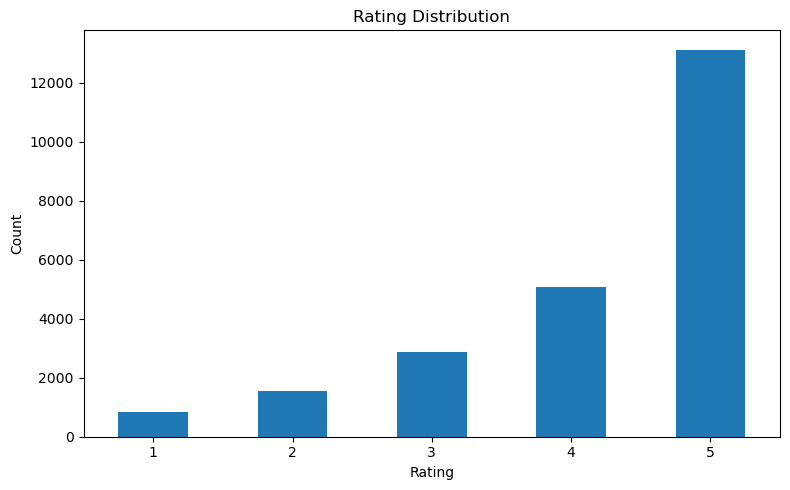

In [25]:
bar_plot(df['Rating'].value_counts().sort_index(), 'Rating Distribution', 'Rating')

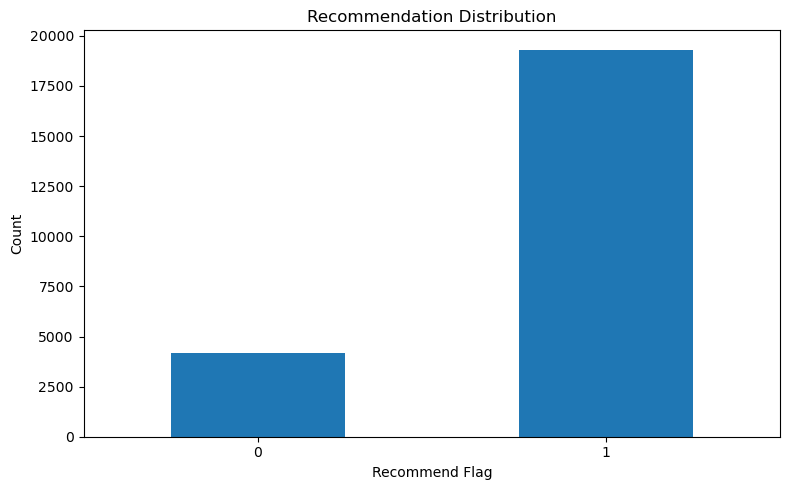

In [26]:
bar_plot(df['Recommend Flag'].value_counts().sort_index(), 'Recommendation Distribution', 'Recommend Flag')

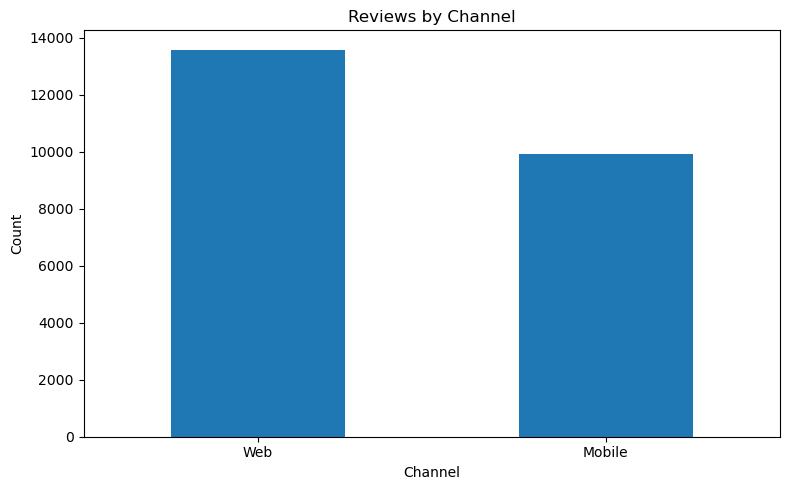

In [27]:
bar_plot(df['Channel'].value_counts(), 'Reviews by Channel', 'Channel')

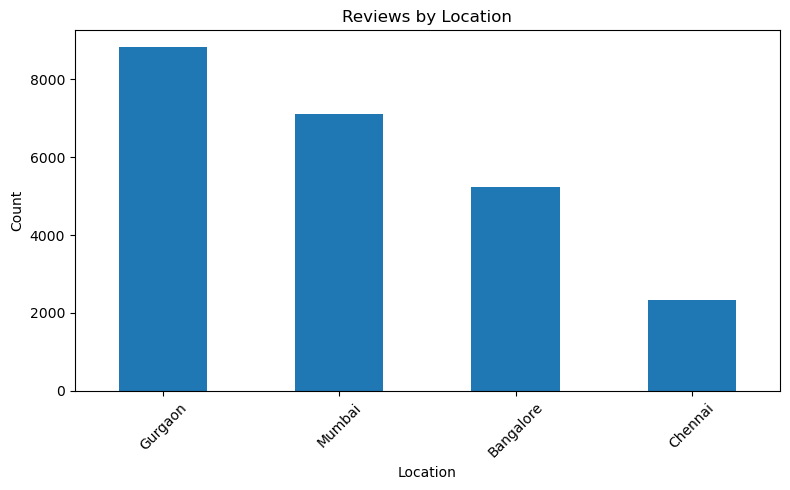

In [28]:
bar_plot(df['Location'].value_counts(), 'Reviews by Location', 'Location', rotation=45)

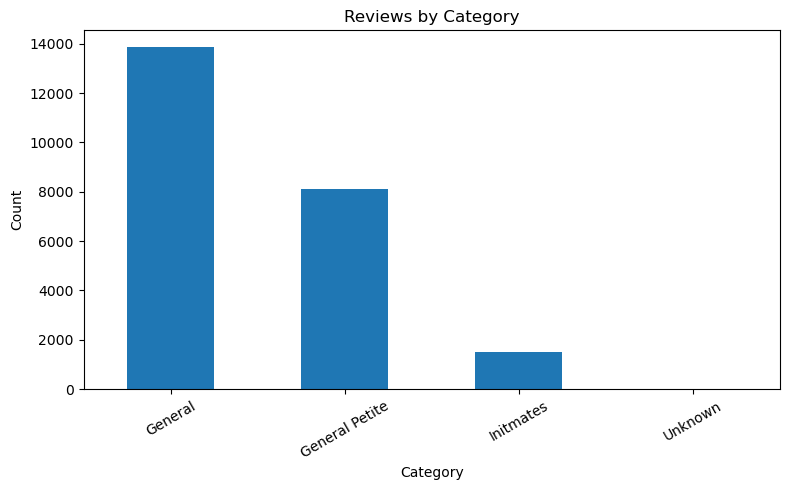

In [29]:
bar_plot(df['Category'].value_counts(), 'Reviews by Category', 'Category', rotation=30)

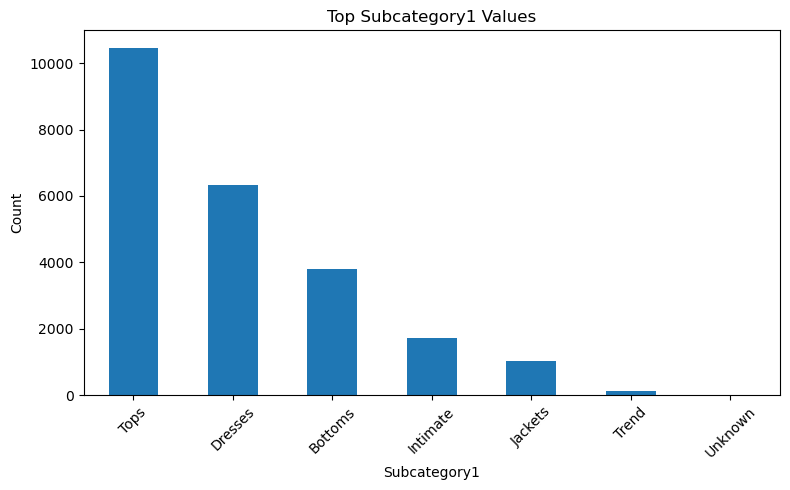

In [30]:
bar_plot(df['Subcategory1'].value_counts().head(15), 'Top Subcategory1 Values', 'Subcategory1', rotation=45)

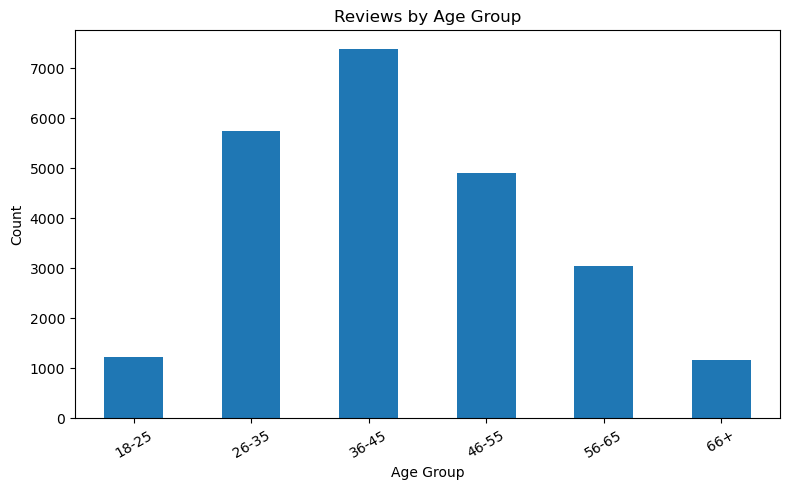

In [31]:
bar_plot(df['Age Group'].value_counts().sort_index(), 'Reviews by Age Group', 'Age Group', rotation=30)

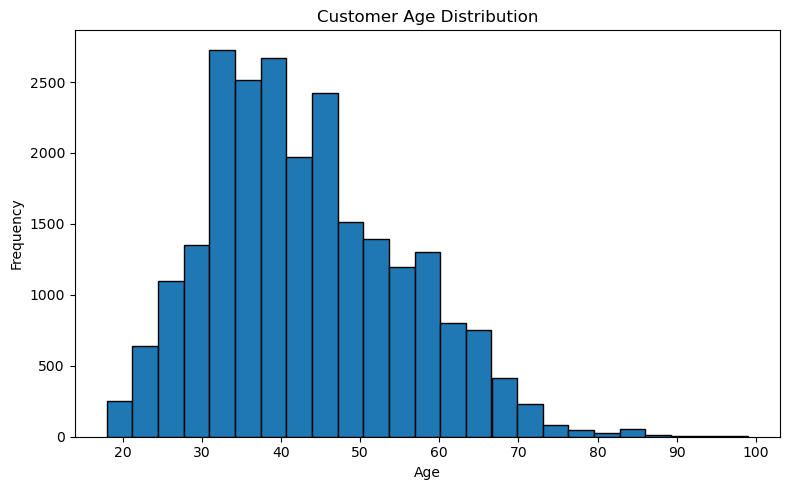

In [32]:
# Customer age distribution.
plt.figure(figsize=(8, 5))
plt.hist(df['Customer Age'], bins=25, edgecolor='black')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


Recommendation rate by Category:
 Category
Unknown           1.000
Initmates         0.852
General Petite    0.826
General           0.817
Name: Recommend Flag, dtype: float64


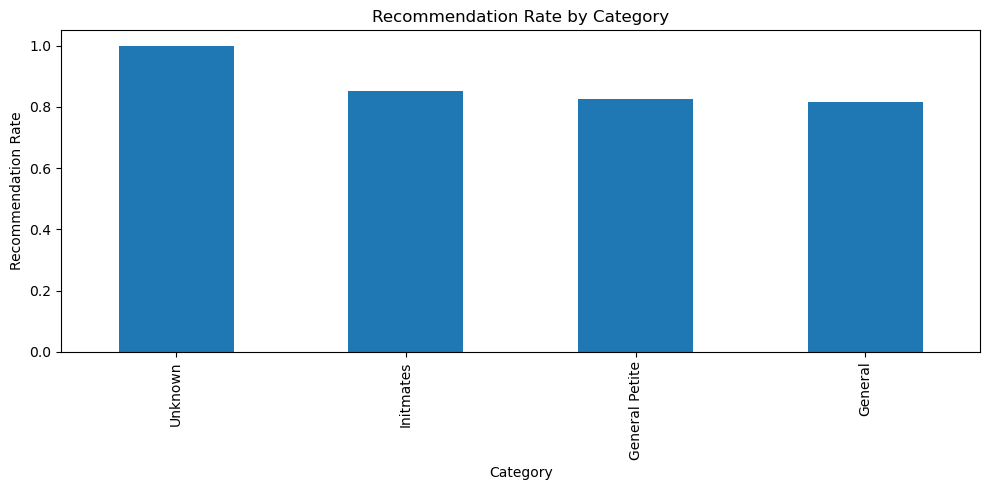


Recommendation rate by Subcategory1:
 Subcategory1
Unknown     1.000
Bottoms     0.851
Intimate    0.850
Jackets     0.836
Tops        0.815
Dresses     0.808
Trend       0.739
Name: Recommend Flag, dtype: float64


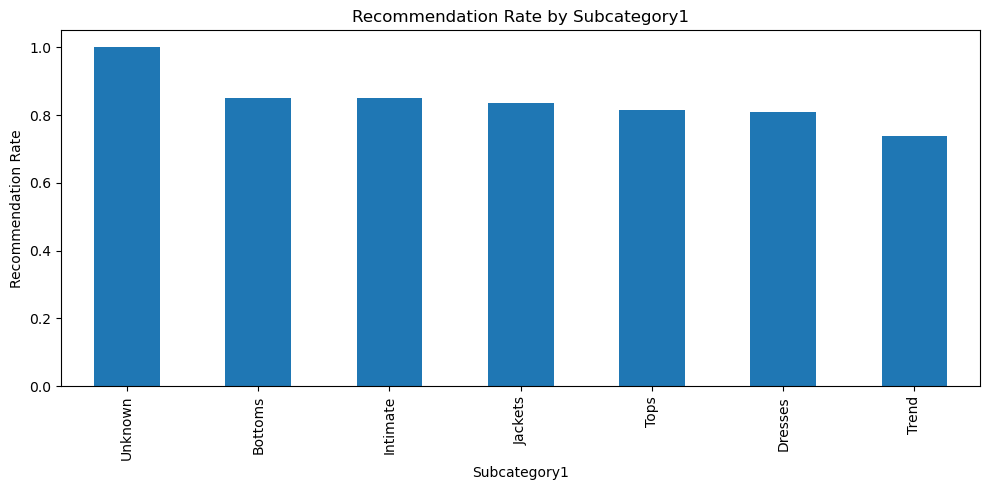


Recommendation rate by SubCategory2:
 SubCategory2
Casual bottoms    1.000
Chemises          1.000
Unknown           1.000
Layering          0.884
Jeans             0.881
Legwear           0.861
Lounge            0.860
Intimates         0.857
Sleep             0.855
Skirts            0.846
Jackets           0.845
Shorts            0.839
Fine gauge        0.837
Pants             0.833
Knits             0.818
Outerwear         0.817
Blouses           0.810
Dresses           0.808
Swim              0.806
Sweaters          0.800
Trend             0.739
Name: Recommend Flag, dtype: float64


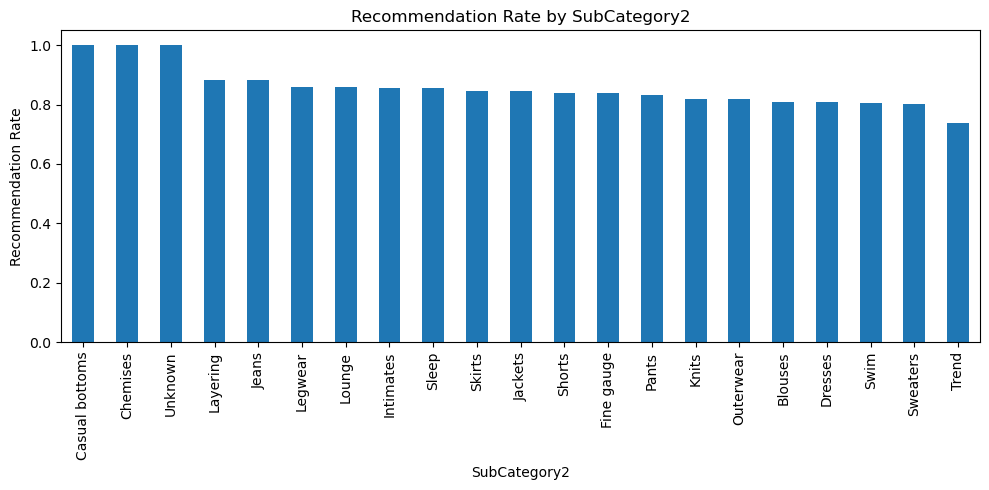


Recommendation rate by Location:
 Location
Chennai      0.826
Mumbai       0.823
Bangalore    0.822
Gurgaon      0.821
Name: Recommend Flag, dtype: float64


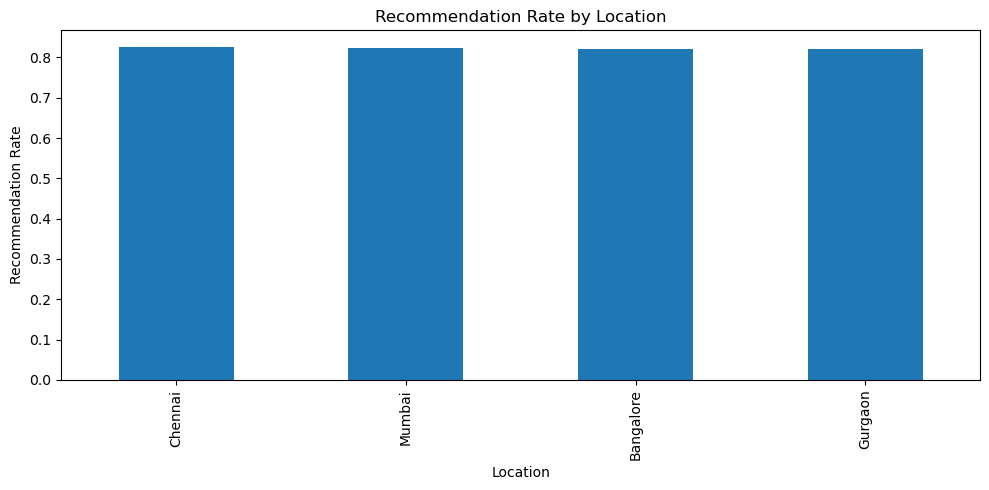


Recommendation rate by Channel:
 Channel
Mobile    0.826
Web       0.820
Name: Recommend Flag, dtype: float64


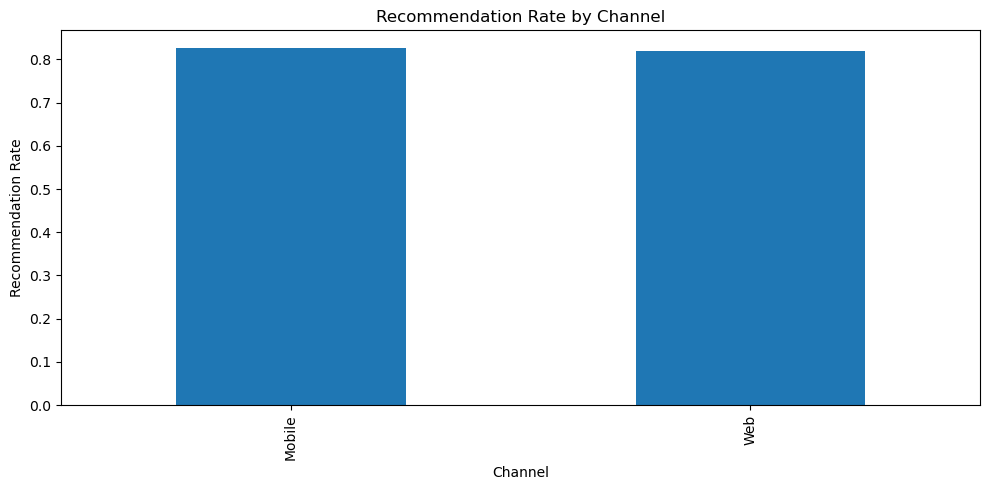


Recommendation rate by Age Group:
 Age Group
56-65    0.851
18-25    0.851
66+      0.846
46-55    0.822
36-45    0.821
26-35    0.799
Name: Recommend Flag, dtype: float64


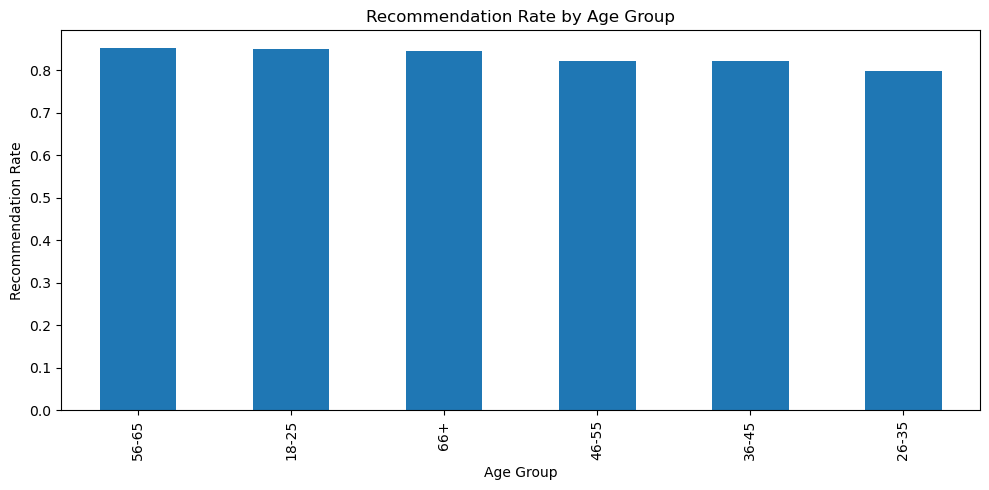

In [33]:
# Recommendation rate by selected dimensions.
for col in ['Category', 'Subcategory1', 'SubCategory2', 'Location', 'Channel', 'Age Group']:
    rate = df.groupby(col, observed=False)['Recommend Flag'].mean().sort_values(ascending=False)
    print(f"\nRecommendation rate by {col}:\n", rate.round(3))
    rate.plot(kind='bar', figsize=(10, 5), title=f'Recommendation Rate by {col}')
    plt.ylabel('Recommendation Rate')
    plt.tight_layout()
    plt.show()

In [34]:
# Average rating by selected dimensions.
for col in ['Category', 'Subcategory1', 'SubCategory2', 'Location', 'Channel', 'Age Group']:
    avg = df.groupby(col, observed=False)['Rating'].mean().sort_values(ascending=False)
    print(f"\nAverage rating by {col}:\n", avg.round(2))


Average rating by Category:
 Category
Unknown           5.00
Initmates         4.29
General Petite    4.21
General           4.18
Name: Rating, dtype: float64

Average rating by Subcategory1:
 Subcategory1
Unknown     5.00
Bottoms     4.29
Intimate    4.28
Jackets     4.26
Tops        4.17
Dresses     4.15
Trend       3.82
Name: Rating, dtype: float64

Average rating by SubCategory2:
 SubCategory2
Unknown           5.00
Casual bottoms    4.50
Layering          4.38
Jeans             4.36
Lounge            4.30
Jackets           4.30
Sleep             4.29
Intimates         4.28
Legwear           4.28
Pants             4.27
Fine gauge        4.26
Shorts            4.26
Skirts            4.25
Outerwear         4.20
Swim              4.20
Sweaters          4.18
Knits             4.16
Blouses           4.15
Dresses           4.15
Chemises          4.00
Trend             3.82
Name: Rating, dtype: float64

Average rating by Location:
 Location
Mumbai       4.21
Chennai      4.20
Gurgaon    

In [35]:
# Product-level summary: only products with at least 10 reviews.
product_summary = df.groupby('Product ID').agg(
    Reviews=('Product ID', 'size'),
    Avg_Rating=('Rating', 'mean'),
    Recommendation_Rate=('Recommend Flag', 'mean')
).query('Reviews >= 10').sort_values(['Recommendation_Rate', 'Reviews'], ascending=[False, False])

print("\nTop products by recommendation rate (min 10 reviews):\n", product_summary.head(20))


Top products by recommendation rate (min 10 reviews):
             Reviews  Avg_Rating  Recommendation_Rate
Product ID                                          
1123             30    4.700000             1.000000
1026             21    4.809524             1.000000
260              15    4.800000             1.000000
674              15    4.733333             1.000000
252              12    4.750000             1.000000
278              12    4.666667             1.000000
417              12    4.666667             1.000000
1151             11    4.636364             1.000000
479              10    4.200000             1.000000
901              10    4.700000             1.000000
1024             35    4.657143             0.971429
520              30    4.400000             0.966667
960              26    4.653846             0.961538
839              48    4.562500             0.958333
967              23    4.565217             0.956522
375              19    4.789474            

## 6. Text Cleaning :

In [36]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [37]:
df['Clean Review'] = df['Combined Review'].apply(clean_text)

In [38]:
# ------------------------------
# SENTIMENT ANALYSIS WITH VADER
# ------------------------------

In [39]:
# VADER is useful for exploratory sentiment. It is not used as the target label.
try:
    import nltk
    from nltk.sentiment import SentimentIntensityAnalyzer
    try:
        sia = SentimentIntensityAnalyzer()
    except LookupError:
        nltk.download('vader_lexicon')
        sia = SentimentIntensityAnalyzer()

    df['Sentiment Score'] = df['Combined Review'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
    df['Sentiment'] = np.select(
        [df['Sentiment Score'] >= 0.05, df['Sentiment Score'] <= -0.05],
        ['Positive', 'Negative'],
        default='Neutral'
    )

    print("\nSentiment distribution:\n", df['Sentiment'].value_counts())
    print("\nSentiment percentages:\n", df['Sentiment'].value_counts(normalize=True).mul(100).round(2))

    for col in ['Channel', 'Location', 'Category', 'Subcategory1', 'Age Group']:
        sentiment_table = pd.crosstab(df[col], df['Sentiment'], normalize='index').mul(100).round(2)
        print(f"\nSentiment % by {col}:\n", sentiment_table)
except Exception as e:
    print("VADER sentiment section skipped:", e)


Sentiment distribution:
 Sentiment
Positive    21165
Negative     1289
Neutral      1029
Name: count, dtype: int64

Sentiment percentages:
 Sentiment
Positive    90.13
Negative     5.49
Neutral      4.38
Name: proportion, dtype: float64

Sentiment % by Channel:
Sentiment  Negative  Neutral  Positive
Channel                               
Mobile         5.34     4.36     90.30
Web            5.60     4.40     90.01

Sentiment % by Location:
 Sentiment  Negative  Neutral  Positive
Location                              
Bangalore      5.53     4.19     90.28
Chennai        5.45     4.64     89.91
Gurgaon        5.72     4.51     89.77
Mumbai         5.19     4.27     90.54

Sentiment % by Category:
 Sentiment       Negative  Neutral  Positive
Category                                   
General             5.65     4.30     90.05
General Petite      5.25     4.19     90.56
Initmates           5.33     6.19     88.48
Unknown             0.00     7.14     92.86

Sentiment % by Subcategory1:

## 7. Frequent Words and Word Clouds :

In [40]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [41]:
positive_text = ' '.join(df.loc[df['Recommend Flag'] == 1, 'Clean Review'])
negative_text = ' '.join(df.loc[df['Recommend Flag'] == 0, 'Clean Review'])

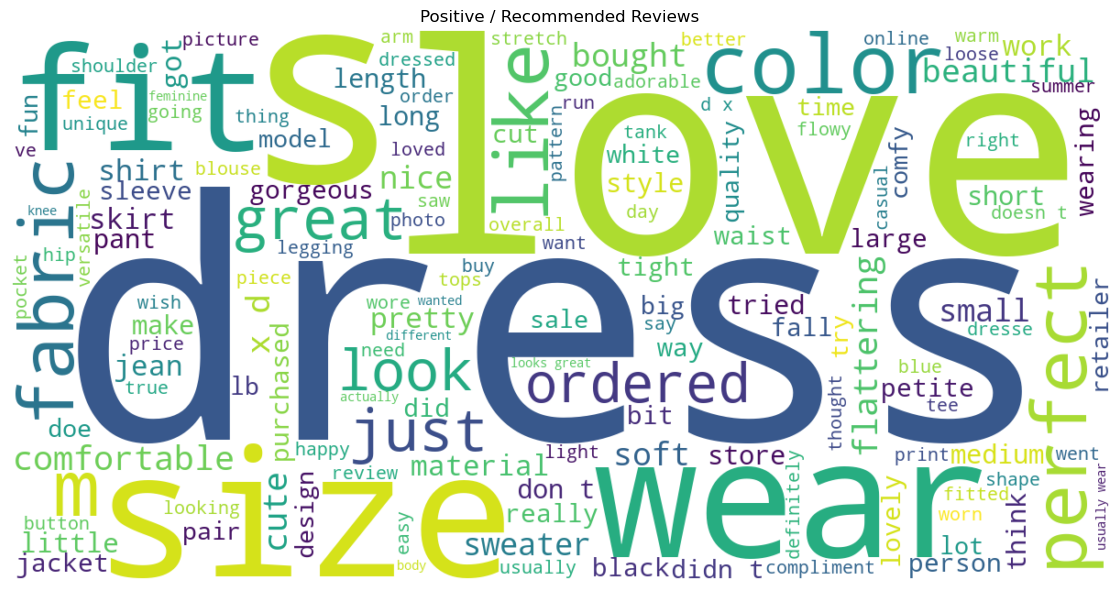

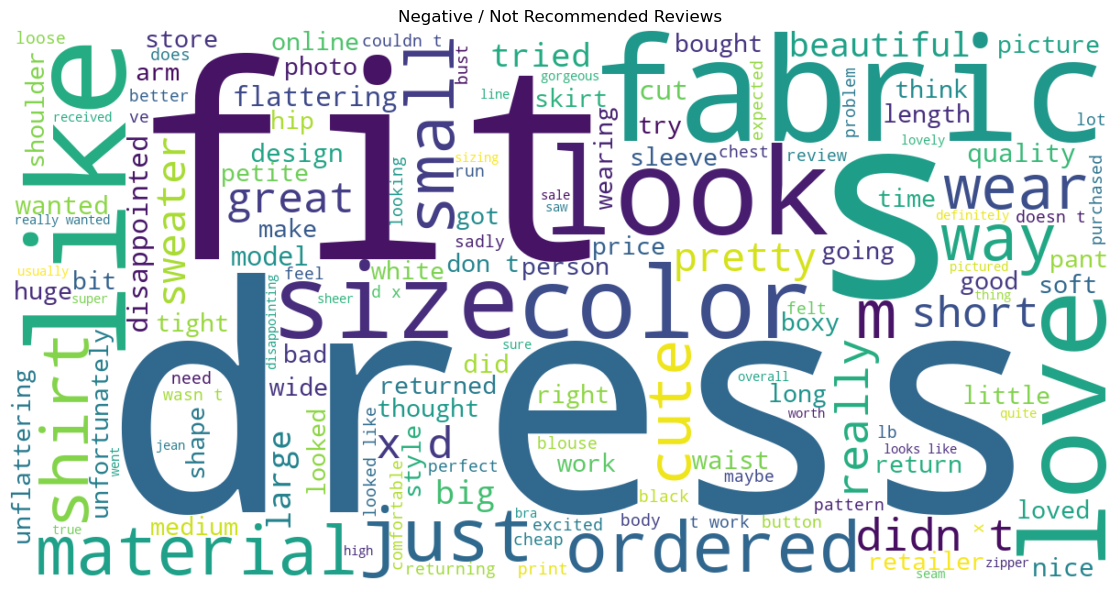

In [42]:
for text, title in [(positive_text, 'Positive / Recommended Reviews'),
                    (negative_text, 'Negative / Not Recommended Reviews')]:
    if text.strip():
        wc = WordCloud(
            width=1200,
            height=600,
            background_color='white',
            stopwords=set(ENGLISH_STOP_WORDS),
            max_words=150
        ).generate(text)
        plt.figure(figsize=(12, 6))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(title)
        plt.tight_layout()
        plt.show()

In [43]:
# Frequent unigram / bigram extraction.
def top_terms(texts, ngram_range=(1, 1), top_n=20):
    vec = CountVectorizer(stop_words='english', ngram_range=ngram_range, min_df=2)
    X = vec.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    idx = counts.argsort()[::-1][:top_n]
    return pd.DataFrame({'Term': terms[idx], 'Count': counts[idx]})

In [44]:
positive_reviews = df.loc[(df['Recommend Flag'] == 1) & (df['Clean Review'] != ''), 'Clean Review']
negative_reviews = df.loc[(df['Recommend Flag'] == 0) & (df['Clean Review'] != ''), 'Clean Review']

In [45]:
print("\nTop positive unigrams:\n", top_terms(positive_reviews, (1, 1), 25))


Top positive unigrams:
            Term  Count
0         dress  10119
1          love   9750
2          size   7748
3         great   7251
4           fit   6405
5          wear   5783
6          like   5509
7          just   4524
8       perfect   4371
9         color   4137
10        small   4056
11         cute   3855
12    beautiful   3760
13       fabric   3712
14       little   3557
15   flattering   3523
16         soft   3473
17  comfortable   3353
18       really   3160
19         look   3149
20         nice   3084
21      ordered   3034
22         fits   2738
23       bought   2714
24          bit   2620


In [46]:
print("\nTop negative unigrams:\n", top_terms(negative_reviews, (1, 1), 25))


Top negative unigrams:
          Term  Count
0       dress   2102
1        like   1879
2         fit   1534
3      fabric   1370
4        just   1310
5        size   1230
6        love   1069
7       small   1013
8        look    998
9      really    915
10    ordered    826
11   material    783
12      color    779
13       wear    773
14       cute    741
15      shirt    714
16        way    703
17    quality    698
18      looks    663
19      great    657
20      large    621
21  beautiful    612
22       didn    604
23     looked    601
24     wanted    579


In [47]:
print("\nTop positive bigrams:\n", top_terms(positive_reviews, (2, 2), 20))


Top positive bigrams:
                 Term  Count
0          true size   1266
1         love dress    843
2          love love    683
3       usually wear    587
4        looks great    584
5      fit perfectly    558
6     fits perfectly    489
7         super cute    477
8         size small    462
9         runs large    426
10        usual size    417
11        just right    415
12  highly recommend    369
13        super soft    351
14   beautiful dress    341
15        runs small    341
16          size fit    336
17  soft comfortable    333
18         fit great    327
19       dress dress    327


In [48]:
print("\nTop negative bigrams:\n", top_terms(negative_reviews, (2, 2), 20))


Top negative bigrams:
              Term  Count
0     wanted love    333
1     looked like    198
2      looks like    172
3   really wanted    167
4       look like    141
5       didn work    132
6      runs small    116
7       felt like    111
8       true size    106
9    poor quality    105
10     love dress    104
11   usually wear    104
12      just didn    101
13     runs large     98
14     size small     87
15    wanted like     78
16      arm holes     74
17      don think     71
18  ordered small     71
19     high hopes     69


## 8. Topic Mining With NMF :

In [49]:
# NMF - Non Negative Matrix factorization : 
# It is an unsupervised machine learning technique used to discover hidden semantic structures and main themes (topics) in a collection of text documents.

In [50]:
text_for_topics = df.loc[df['Clean Review'] != '', 'Clean Review']

In [51]:
topic_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    min_df=5,
    max_df=0.90,
    ngram_range=(1, 2)
)

In [52]:
X_topics = topic_vectorizer.fit_transform(text_for_topics)

In [53]:
N_TOPICS = 8
nmf = NMF(n_components=N_TOPICS, random_state=42, init='nndsvda', max_iter=400)

In [54]:
W = nmf.fit_transform(X_topics)

In [55]:
H = nmf.components_

In [56]:
terms = np.array(topic_vectorizer.get_feature_names_out())

In [57]:
print("\nTOPICS")

for topic_idx, weights in enumerate(H):
    top_words = terms[weights.argsort()[::-1][:12]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")


TOPICS
Topic 1: like, fabric, just, look, really, nice, pretty, fit, didn, color, skirt, good
Topic 2: dress, love dress, beautiful, beautiful dress, dress dress, perfect, flattering, summer, great dress, slip, wear, dress beautiful
Topic 3: love, love love, love dress, absolutely, color, absolutely love, colors, compliments, fits, wanted love, love color, bought
Topic 4: size, small, large, runs, medium, ordered, usually, wear, true, big, fit, xs
Topic 5: sweater, soft, love sweater, beautiful, warm, cozy, color, sleeves, coat, beautiful sweater, fall, itchy
Topic 6: cute, super, super cute, comfy, really cute, little, really, comfortable, cute comfortable, cute comfy, cute dress, super soft
Topic 7: great, jeans, pants, perfect, comfortable, fit, wear, summer, pair, soft, fall, looks great
Topic 8: shirt, love shirt, white, great shirt, shirt love, soft, tee, cute shirt, shirts, shirt great, material, shirt shirt


In [58]:
# Dominant topic back to rows used in topic model.
topic_rows = text_for_topics.index
df.loc[topic_rows, 'Dominant Topic'] = W.argmax(axis=1) + 1
print("\nDominant topic distribution:\n", df['Dominant Topic'].value_counts().sort_index())


Dominant topic distribution:
 Dominant Topic
1.0    3931
2.0    3830
3.0    2039
4.0    4134
5.0    1753
6.0    1784
7.0    3545
8.0    1626
Name: count, dtype: int64


## 9. Recommendation Classification Data Preparation :

In [59]:
# Rating is intentionally excluded by default to reduce outcome leakage.
# Product ID is treated as categorical because it identifies product differences.

In [60]:
model_df = df.copy()

In [61]:
TEXT_COL = 'Clean Review'
CAT_COLS = ['Product ID', 'Category', 'Subcategory1', 'SubCategory2', 'Location', 'Channel']
NUM_COLS = ['Customer Age', 'Has Review Text']
TARGET = 'Recommend Flag'

In [62]:
X = model_df[[TEXT_COL] + CAT_COLS + NUM_COLS]
y = model_df[TARGET].astype(int)

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [64]:
# TF-IDF fitted only on training data.
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=3500,
    min_df=3,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True
)

In [65]:
Xtr_text = tfidf.fit_transform(X_train[TEXT_COL])

In [66]:
Xte_text = tfidf.transform(X_test[TEXT_COL])

In [67]:
# One-hot encode categorical columns.
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

In [68]:
Xtr_cat = ohe.fit_transform(X_train[CAT_COLS].astype(str))

In [69]:
Xte_cat = ohe.transform(X_test[CAT_COLS].astype(str))

In [70]:
# Scale numeric columns to non-negative [0, 1], compatible with MultinomialNB.
scaler = MinMaxScaler()

In [71]:
Xtr_num = csr_matrix(scaler.fit_transform(X_train[NUM_COLS]))

In [72]:
Xte_num = csr_matrix(scaler.transform(X_test[NUM_COLS]))

In [73]:
# Full sparse design matrix.
X_train_final = hstack([Xtr_text, Xtr_cat, Xtr_num], format='csr')
X_test_final = hstack([Xte_text, Xte_cat, Xte_num], format='csr')

In [74]:
feature_names = np.concatenate([
    np.array([f"TEXT__{x}" for x in tfidf.get_feature_names_out()]),
    np.array([f"CAT__{x}" for x in ohe.get_feature_names_out(CAT_COLS)]),
    np.array([f"NUM__{x}" for x in NUM_COLS])
])

In [75]:
print("\nTraining matrix:", X_train_final.shape)
print("Testing matrix:", X_test_final.shape)


Training matrix: (18786, 4653)
Testing matrix: (4697, 4653)


## 10. Evaluation Function :

In [76]:
results = []
trained_models = {}

In [77]:
def evaluate_model(name, model, Xte=X_test_final, yte=y_test):
    pred = model.predict(Xte)

    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(Xte)[:, 1]
        auc = roc_auc_score(yte, prob)
    elif hasattr(model, 'decision_function'):
        score = model.decision_function(Xte)
        auc = roc_auc_score(yte, score)
    else:
        auc = np.nan

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(yte, pred),
        'Balanced Accuracy': balanced_accuracy_score(yte, pred),
        'Precision': precision_score(yte, pred, zero_division=0),
        'Recall': recall_score(yte, pred, zero_division=0),
        'F1': f1_score(yte, pred, zero_division=0),
        'ROC_AUC': auc
    }
    results.append(metrics)
    trained_models[name] = model

    print("\n" + '=' * 70)
    print(name)
    print('=' * 70)
    print(pd.Series(metrics))
    print("\nClassification report:\n", classification_report(yte, pred, digits=4))
    print("\nConfusion matrix:\n", confusion_matrix(yte, pred))

    ConfusionMatrixDisplay.from_predictions(yte, pred)
    plt.title(name)
    plt.tight_layout()
    plt.show()

    return metrics

In [78]:
# Common cross-validation setup.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = 'roc_auc'
N_JOBS = 2

## 11. Logistic Regression Algorithm using GridSearchCV :

In [79]:
lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='liblinear',
    random_state=42
)

In [80]:
lr_grid = {
    'C': [0.1, 0.5, 1, 2, 5],
    'penalty': ['l1', 'l2']
}

In [81]:
lr_search = GridSearchCV(
    lr, lr_grid, cv=cv, scoring=SCORING,
    n_jobs=N_JOBS, verbose=1, refit=True
)

In [82]:
lr_search.fit(X_train_final, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=2000, random_state=42,
                                          solver='liblinear'),
             n_jobs=2,
             param_grid={'C': [0.1, 0.5, 1, 2, 5], 'penalty': ['l1', 'l2']},
             scoring='roc_auc', verbose=1)

In [83]:
print("Best Logistic Regression params:", lr_search.best_params_)

Best Logistic Regression params: {'C': 1, 'penalty': 'l2'}


In [84]:
print("Best CV ROC-AUC:", lr_search.best_score_)

Best CV ROC-AUC: 0.9378365858135684



Logistic Regression
Model                Logistic Regression
Accuracy                         0.87822
Balanced Accuracy               0.859682
Precision                       0.960537
Recall                          0.888429
F1                              0.923077
ROC_AUC                         0.933163
dtype: object

Classification report:
               precision    recall  f1-score   support

           0     0.6165    0.8309    0.7079       834
           1     0.9605    0.8884    0.9231      3863

    accuracy                         0.8782      4697
   macro avg     0.7885    0.8597    0.8155      4697
weighted avg     0.8995    0.8782    0.8849      4697


Confusion matrix:
 [[ 693  141]
 [ 431 3432]]


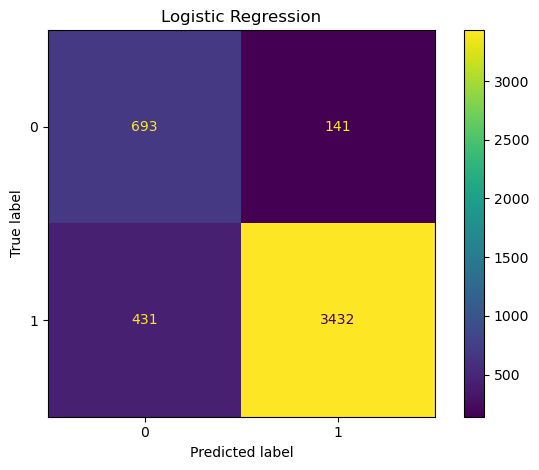

{'Model': 'Logistic Regression',
 'Accuracy': 0.8782201405152225,
 'Balanced Accuracy': np.float64(0.8596819670848876),
 'Precision': 0.9605373635600336,
 'Recall': 0.8884286823712141,
 'F1': 0.9230769230769231,
 'ROC_AUC': np.float64(0.9331631769396804)}

In [85]:
evaluate_model('Logistic Regression', lr_search.best_estimator_)

In [86]:
# OPTIONAL RFE FOR LOGISTIC REGRESSION
# RFE on thousands of sparse TF-IDF features is computationally expensive.
# Run this only if explicitly needed and enough RAM/time is available.
RUN_RFE_LOGISTIC = False
if RUN_RFE_LOGISTIC:
    rfe_lr_estimator = LogisticRegression(
        C=lr_search.best_params_['C'],
        penalty='l2',
        solver='liblinear',
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
    rfe_lr = RFE(
        estimator=rfe_lr_estimator,
        n_features_to_select=min(800, X_train_final.shape[1]),
        step=0.20,
        verbose=1
    )
    Xtr_lr_rfe = rfe_lr.fit_transform(X_train_final, y_train)
    Xte_lr_rfe = rfe_lr.transform(X_test_final)
    lr_rfe_model = rfe_lr_estimator.fit(Xtr_lr_rfe, y_train)
    evaluate_model('Logistic Regression + RFE', lr_rfe_model, Xte_lr_rfe, y_test)



## 12. KNN Classifier Algorithm using GridSearchCV :

In [87]:
# KNN can be slow in high-dimensional sparse NLP space.

In [88]:
knn = KNeighborsClassifier()
knn_grid = {
    'n_neighbors': [25],
    'weights': ['uniform'],
    'metric': ['euclidean']
}
knn_search = GridSearchCV(
    knn, knn_grid, cv=3, scoring=SCORING,
    n_jobs=N_JOBS, verbose=1, refit=True
)

In [89]:
knn_search.fit(X_train_final, y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


GridSearchCV(cv=3, estimator=KNeighborsClassifier(), n_jobs=2,
             param_grid={'metric': ['euclidean'], 'n_neighbors': [25],
                         'weights': ['uniform']},
             scoring='roc_auc', verbose=1)

In [90]:
print("Best KNN params:", knn_search.best_params_)

Best KNN params: {'metric': 'euclidean', 'n_neighbors': 25, 'weights': 'uniform'}


In [91]:
print("Best CV ROC-AUC:", knn_search.best_score_)

Best CV ROC-AUC: 0.6861513217901473



KNN Classifier
Model                KNN Classifier
Accuracy                   0.823079
Balanced Accuracy          0.502739
Precision                  0.823241
Recall                     0.999482
F1                         0.902841
ROC_AUC                    0.689049
dtype: object

Classification report:
               precision    recall  f1-score   support

           0     0.7143    0.0060    0.0119       834
           1     0.8232    0.9995    0.9028      3863

    accuracy                         0.8231      4697
   macro avg     0.7688    0.5027    0.4574      4697
weighted avg     0.8039    0.8231    0.7446      4697


Confusion matrix:
 [[   5  829]
 [   2 3861]]


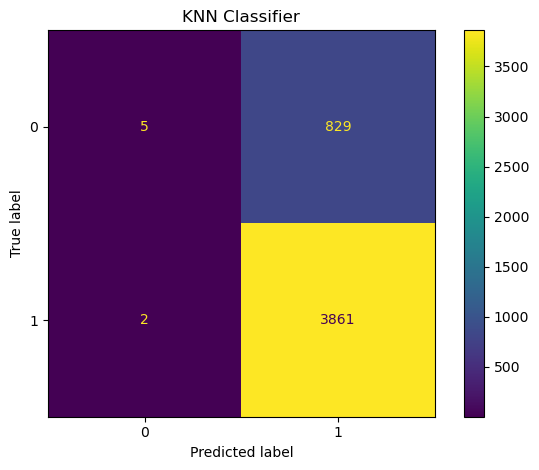

{'Model': 'KNN Classifier',
 'Accuracy': 0.8230785607834789,
 'Balanced Accuracy': np.float64(0.5027387357522731),
 'Precision': 0.8232409381663113,
 'Recall': 0.9994822676676158,
 'F1': 0.9028411083830234,
 'ROC_AUC': np.float64(0.6890485023319682)}

In [92]:
evaluate_model('KNN Classifier', knn_search.best_estimator_)

In [93]:
# RFE is not appropriate for KNN because KNN has no coefficients or feature_importances_.

## 13. Multinomial Naive Bayes Algorithm using GridSearchCV :

In [94]:
# MultinomialNB is more suitable than GaussianNB for non-negative sparse NLP features.

In [95]:
nb = MultinomialNB()
nb_grid = {
    'alpha': [0.05, 0.1, 0.25, 0.5, 1.0, 2.0],
    'fit_prior': [True, False]
}
nb_search = GridSearchCV(
    nb, nb_grid, cv=cv, scoring=SCORING,
    n_jobs=N_JOBS, verbose=1, refit=True
)

In [96]:
nb_search.fit(X_train_final, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=MultinomialNB(), n_jobs=2,
             param_grid={'alpha': [0.05, 0.1, 0.25, 0.5, 1.0, 2.0],
                         'fit_prior': [True, False]},
             scoring='roc_auc', verbose=1)

In [97]:
print("Best Naive Bayes params:", nb_search.best_params_)

Best Naive Bayes params: {'alpha': 0.5, 'fit_prior': True}


In [98]:
print("Best CV ROC-AUC:", nb_search.best_score_)

Best CV ROC-AUC: 0.9130408011108628



Multinomial Naive Bayes
Model                Multinomial Naive Bayes
Accuracy                            0.878859
Balanced Accuracy                   0.712933
Precision                           0.891956
Recall                               0.97023
F1                                  0.929448
ROC_AUC                             0.911598
dtype: object

Classification report:
               precision    recall  f1-score   support

           0     0.7677    0.4556    0.5719       834
           1     0.8920    0.9702    0.9294      3863

    accuracy                         0.8789      4697
   macro avg     0.8298    0.7129    0.7507      4697
weighted avg     0.8699    0.8789    0.8660      4697


Confusion matrix:
 [[ 380  454]
 [ 115 3748]]


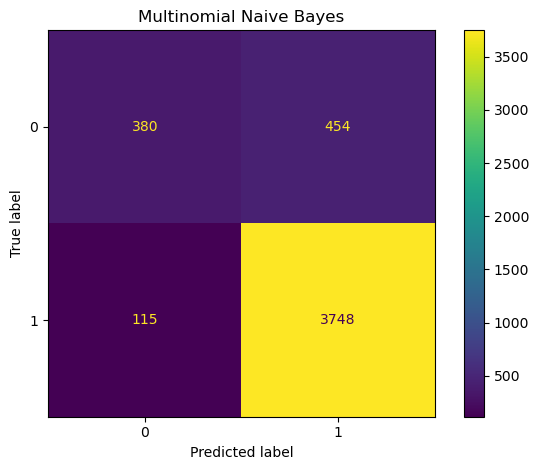

{'Model': 'Multinomial Naive Bayes',
 'Accuracy': 0.8788588460719609,
 'Balanced Accuracy': np.float64(0.7129329412473128),
 'Precision': 0.8919562113279391,
 'Recall': 0.970230390887911,
 'F1': 0.9294482331060137,
 'ROC_AUC': np.float64(0.9115984458097514)}

In [99]:
evaluate_model('Multinomial Naive Bayes', nb_search.best_estimator_)

In [100]:
# RFE is usually not used with MultinomialNB in this sparse NLP setting.

## 14. Decision Tree Algorithm using GridSearchCV :

In [101]:
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_grid = {
    'criterion': ['entropy'],
    'max_depth': [20],
    'min_samples_split': [25],
    'min_samples_leaf': [10],
    'max_features': [None]
}
dt_search = GridSearchCV(
    dt, dt_grid, cv=3, scoring=SCORING,
    n_jobs=N_JOBS, verbose=1, refit=True
)

In [102]:
dt_search.fit(X_train_final, y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


GridSearchCV(cv=3,
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=2,
             param_grid={'criterion': ['entropy'], 'max_depth': [20],
                         'max_features': [None], 'min_samples_leaf': [10],
                         'min_samples_split': [25]},
             scoring='roc_auc', verbose=1)

In [103]:
print("Best Decision Tree params:", dt_search.best_params_)

Best Decision Tree params: {'criterion': 'entropy', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 25}


In [104]:
print("Best CV ROC-AUC:", dt_search.best_score_)

Best CV ROC-AUC: 0.782959675794859



Decision Tree Classifier
Model                Decision Tree Classifier
Accuracy                             0.718757
Balanced Accuracy                    0.744403
Precision                            0.937974
Recall                               0.704634
F1                                    0.80473
ROC_AUC                              0.804877
dtype: object

Classification report:
               precision    recall  f1-score   support

           0     0.3643    0.7842    0.4975       834
           1     0.9380    0.7046    0.8047      3863

    accuracy                         0.7188      4697
   macro avg     0.6512    0.7444    0.6511      4697
weighted avg     0.8361    0.7188    0.7502      4697


Confusion matrix:
 [[ 654  180]
 [1141 2722]]


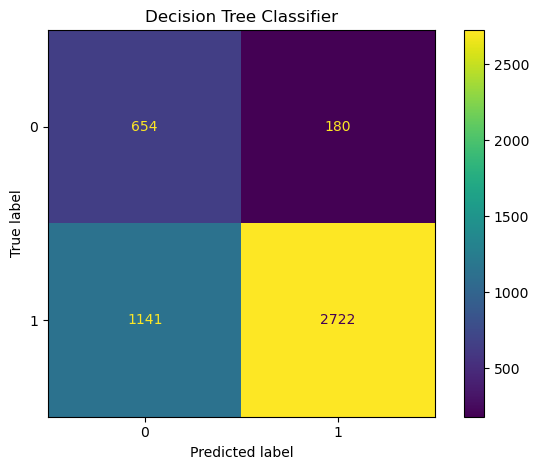

{'Model': 'Decision Tree Classifier',
 'Accuracy': 0.7187566531828827,
 'Balanced Accuracy': np.float64(0.744403183122671),
 'Precision': 0.937973811164714,
 'Recall': 0.7046337043748382,
 'F1': 0.804730229120473,
 'ROC_AUC': np.float64(0.8048766785173984)}

In [105]:
evaluate_model('Decision Tree Classifier', dt_search.best_estimator_)

In [106]:
# OPTIONAL RFE: technically possible because a tree exposes feature_importances_,
# but generally not efficient for large sparse text matrices.
RUN_RFE_TREE = False
if RUN_RFE_TREE:
    rfe_dt = RFE(
        estimator=DecisionTreeClassifier(
            max_depth=10,
            class_weight='balanced',
            random_state=42
        ),
        n_features_to_select=min(800, X_train_final.shape[1]),
        step=0.20,
        verbose=1
    )
    Xtr_dt_rfe = rfe_dt.fit_transform(X_train_final, y_train)
    Xte_dt_rfe = rfe_dt.transform(X_test_final)
    dt_rfe_model = dt_search.best_estimator_.fit(Xtr_dt_rfe, y_train)
    evaluate_model('Decision Tree + RFE', dt_rfe_model, Xte_dt_rfe, y_test)



## 15. Bagging Classifier Algorithm using GridSearchCV :

In [107]:
base_tree = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42
)

bag = BaggingClassifier(
    estimator=base_tree,
    random_state=42,
    n_jobs=N_JOBS
)

bag_grid = {
    'n_estimators': [50],
    'max_samples': [0.6],
    'max_features': [0.6],
    'bootstrap': [True]
}

bag_search = GridSearchCV(
    bag, bag_grid, cv=3, scoring=SCORING,
    n_jobs=N_JOBS, verbose=1, refit=True
)


In [108]:
bag_search.fit(X_train_final, y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


GridSearchCV(cv=3,
             estimator=BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                          max_depth=12,
                                                                          min_samples_leaf=3,
                                                                          random_state=42),
                                         n_jobs=2, random_state=42),
             n_jobs=2,
             param_grid={'bootstrap': [True], 'max_features': [0.6],
                         'max_samples': [0.6], 'n_estimators': [50]},
             scoring='roc_auc', verbose=1)

In [109]:
print("Best Bagging params:", bag_search.best_params_)

Best Bagging params: {'bootstrap': True, 'max_features': 0.6, 'max_samples': 0.6, 'n_estimators': 50}


In [110]:
print("Best CV ROC-AUC:", bag_search.best_score_)

Best CV ROC-AUC: 0.8734434353492967



Bagging Classifier
Model                Bagging Classifier
Accuracy                       0.819885
Balanced Accuracy               0.78661
Precision                      0.936109
Recall                         0.838209
F1                             0.884458
ROC_AUC                        0.881196
dtype: object

Classification report:
               precision    recall  f1-score   support

           0     0.4952    0.7350    0.5917       834
           1     0.9361    0.8382    0.8845      3863

    accuracy                         0.8199      4697
   macro avg     0.7156    0.7866    0.7381      4697
weighted avg     0.8578    0.8199    0.8325      4697


Confusion matrix:
 [[ 613  221]
 [ 625 3238]]


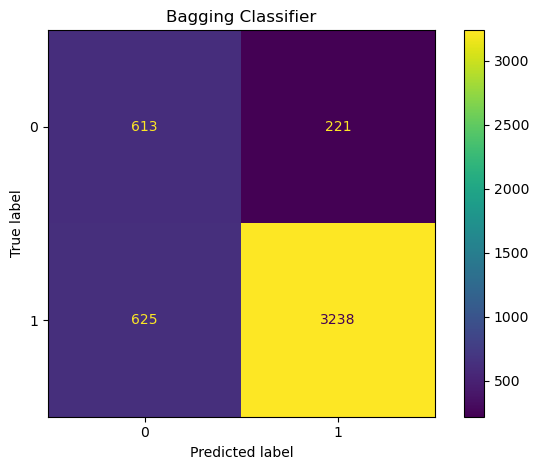

{'Model': 'Bagging Classifier',
 'Accuracy': 0.8198850329997871,
 'Balanced Accuracy': np.float64(0.7866103182688123),
 'Precision': 0.936108701936976,
 'Recall': 0.8382086461299508,
 'F1': 0.8844577984157334,
 'ROC_AUC': np.float64(0.8811961044677072)}

In [111]:
evaluate_model('Bagging Classifier', bag_search.best_estimator_)

In [112]:
# Standard RFE is not directly appropriate for BaggingClassifier because the ensemble
# itself does not provide one simple coef_ / feature_importances_ vector for RFE.

## 16. Random Forest Algorithm using GridSearchCV :

In [113]:
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=N_JOBS
)

rf_grid = {
    'n_estimators': [150],
    'max_depth': [None],
    'min_samples_split': [6],
    'min_samples_leaf': [1],
    'max_features': ['sqrt']
}

rf_search = GridSearchCV(
    rf, rf_grid, cv=3, scoring=SCORING,
    n_jobs=N_JOBS, verbose=1, refit=True
)

In [114]:
rf_search.fit(X_train_final, y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


GridSearchCV(cv=3,
             estimator=RandomForestClassifier(class_weight='balanced', n_jobs=2,
                                              random_state=42),
             n_jobs=2,
             param_grid={'max_depth': [None], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1], 'min_samples_split': [6],
                         'n_estimators': [150]},
             scoring='roc_auc', verbose=1)

In [115]:
print("Best Random Forest params:", rf_search.best_params_)

Best Random Forest params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 150}


In [116]:
print("Best CV ROC-AUC:", rf_search.best_score_)

Best CV ROC-AUC: 0.9203853731616642



Random Forest Classifier
Model                Random Forest Classifier
Accuracy                             0.895252
Balanced Accuracy                    0.752985
Precision                            0.906047
Recall                               0.973596
F1                                   0.938607
ROC_AUC                              0.927678
dtype: object

Classification report:
               precision    recall  f1-score   support

           0     0.8132    0.5324    0.6435       834
           1     0.9060    0.9736    0.9386      3863

    accuracy                         0.8953      4697
   macro avg     0.8596    0.7530    0.7910      4697
weighted avg     0.8896    0.8953    0.8862      4697


Confusion matrix:
 [[ 444  390]
 [ 102 3761]]


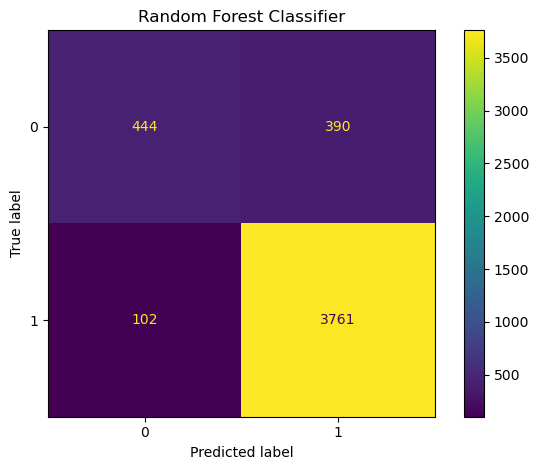

{'Model': 'Random Forest Classifier',
 'Accuracy': 0.8952522886949117,
 'Balanced Accuracy': np.float64(0.7529848758839162),
 'Precision': 0.906046735726331,
 'Recall': 0.973595651048408,
 'F1': 0.9386074369852758,
 'ROC_AUC': np.float64(0.9276779456579702)}

In [117]:
evaluate_model('Random Forest Classifier', rf_search.best_estimator_)

In [118]:
# OPTIONAL RFE FOR RANDOM FOREST - usually expensive on NLP feature matrices.
RUN_RFE_RF = False
if RUN_RFE_RF:
    rfe_rf = RFE(
        estimator=RandomForestClassifier(
            n_estimators=150,
            max_depth=15,
            class_weight='balanced',
            random_state=42,
            n_jobs=N_JOBS
        ),
        n_features_to_select=min(800, X_train_final.shape[1]),
        step=0.25,
        verbose=1
    )
    Xtr_rf_rfe = rfe_rf.fit_transform(X_train_final, y_train)
    Xte_rf_rfe = rfe_rf.transform(X_test_final)
    rf_rfe_model = rf_search.best_estimator_.fit(Xtr_rf_rfe, y_train)
    evaluate_model('Random Forest + RFE', rf_rfe_model, Xte_rf_rfe, y_test)

## 17. XGBoost Classifier Algorithm using GridSearchCV :

In [119]:
# scale_pos_weight = negatives / positives for class 1 weighting is generally <1 here;
# however we keep evaluation stratified and tune regularization rather than force it.

In [120]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    tree_method='hist',
    n_jobs=N_JOBS
)

xgb_grid = {
    'n_estimators': [125],
    'learning_rate': [0.03]
}

xgb_search = GridSearchCV(
    xgb, xgb_grid, cv=3, scoring=SCORING,
    n_jobs=N_JOBS, verbose=1, refit=True
)

In [121]:
xgb_search.fit(X_train_final, y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=2, num_parallel_tree=None, ...),
             n_jobs=2,
             param_grid={'learning_rate': [0.03], 'n_estimators': [125]},
             scoring='roc_auc', verbose=1)

In [122]:
print("Best XGBoost params:", xgb_search.best_params_)

Best XGBoost params: {'learning_rate': 0.03, 'n_estimators': 125}


In [123]:
print("Best CV ROC-AUC:", xgb_search.best_score_)

Best CV ROC-AUC: 0.8892308658356676



XGBoost Classifier
Model                XGBoost Classifier
Accuracy                       0.865446
Balanced Accuracy              0.641787
Precision                      0.866576
Recall                          0.98861
F1                             0.923579
ROC_AUC                        0.898028
dtype: object

Classification report:
               precision    recall  f1-score   support

           0     0.8483    0.2950    0.4377       834
           1     0.8666    0.9886    0.9236      3863

    accuracy                         0.8654      4697
   macro avg     0.8574    0.6418    0.6807      4697
weighted avg     0.8633    0.8654    0.8373      4697


Confusion matrix:
 [[ 246  588]
 [  44 3819]]


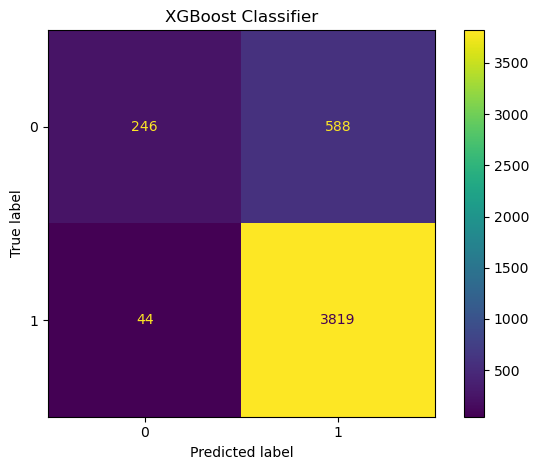

{'Model': 'XGBoost Classifier',
 'Accuracy': 0.8654460293804556,
 'Balanced Accuracy': np.float64(0.6417869587322634),
 'Precision': 0.866575901974132,
 'Recall': 0.9886098886875485,
 'F1': 0.9235792019347038,
 'ROC_AUC': np.float64(0.8980279923097505)}

In [124]:
evaluate_model('XGBoost Classifier', xgb_search.best_estimator_)

In [125]:
# RFE is technically possible with XGBoost but is usually prohibitively expensive
# when nested around boosted-tree training and thousands of NLP features.

## 18. Model Comparison :

In [126]:
results_df = pd.DataFrame(results).sort_values('ROC_AUC', ascending=False)
print("\nFINAL MODEL COMPARISON\n", results_df.round(4))


FINAL MODEL COMPARISON
                       Model  Accuracy  Balanced Accuracy  Precision  Recall  \
0       Logistic Regression    0.8782             0.8597     0.9605  0.8884   
5  Random Forest Classifier    0.8953             0.7530     0.9060  0.9736   
2   Multinomial Naive Bayes    0.8789             0.7129     0.8920  0.9702   
6        XGBoost Classifier    0.8654             0.6418     0.8666  0.9886   
4        Bagging Classifier    0.8199             0.7866     0.9361  0.8382   
3  Decision Tree Classifier    0.7188             0.7444     0.9380  0.7046   
1            KNN Classifier    0.8231             0.5027     0.8232  0.9995   

       F1  ROC_AUC  
0  0.9231   0.9332  
5  0.9386   0.9277  
2  0.9294   0.9116  
6  0.9236   0.8980  
4  0.8845   0.8812  
3  0.8047   0.8049  
1  0.9028   0.6890  


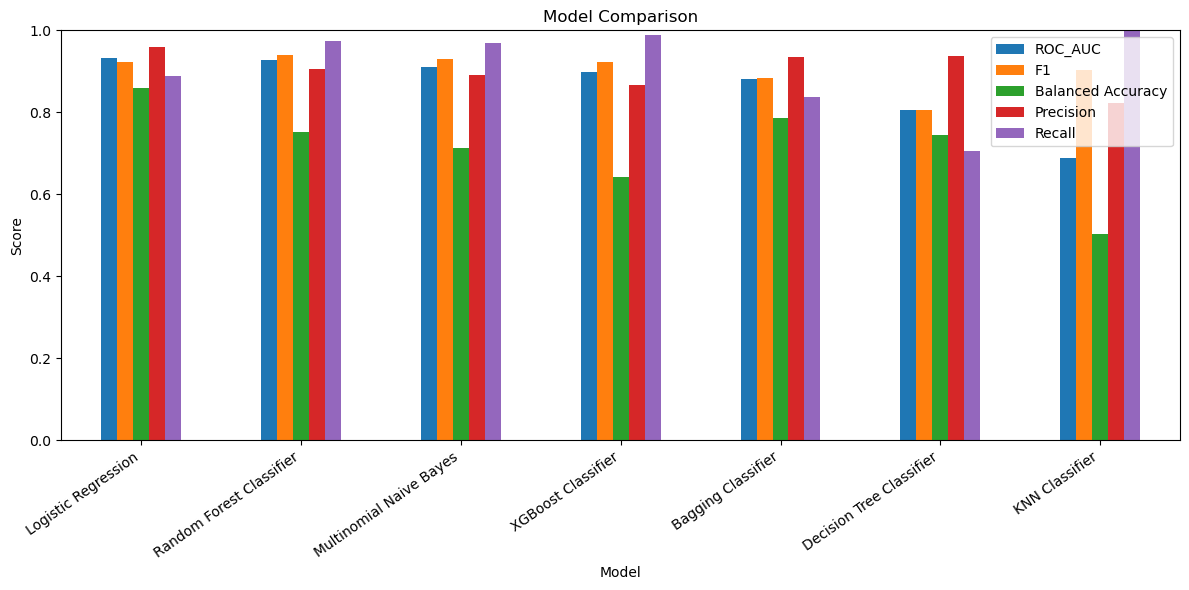

In [127]:
results_df.set_index('Model')[['ROC_AUC', 'F1', 'Balanced Accuracy', 'Precision', 'Recall']].plot(
    kind='bar', figsize=(12, 6)
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 19. Driver / Feature Importance Analysis :

In [128]:
# Logistic coefficients are especially useful for interpreting positive/negative drivers.

In [129]:
best_lr = lr_search.best_estimator_

In [130]:
coef = best_lr.coef_.ravel()

In [131]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef
}).sort_values('Coefficient')

In [132]:
print("\nTop drivers of NOT recommending (negative coefficients):\n", coef_df.head(30))
print("\nTop drivers of recommending (positive coefficients):\n", coef_df.tail(30).sort_values('Coefficient', ascending=False))


Top drivers of NOT recommending (negative coefficients):
                   Feature  Coefficient
685    TEXT__disappointed    -6.235986
3291    TEXT__wanted love    -5.880409
3196   TEXT__unflattering    -4.384019
1383           TEXT__huge    -4.331751
2465       TEXT__returned    -4.222381
2467      TEXT__returning    -4.191480
110             TEXT__bad    -4.117486
2260           TEXT__poor    -3.976927
360           TEXT__cheap    -3.748071
2463         TEXT__return    -3.445376
687   TEXT__disappointing    -3.367607
905          TEXT__fabric    -3.328335
2919        TEXT__strange    -3.282592
1906            TEXT__meh    -3.245399
2030            TEXT__odd    -3.146036
3198  TEXT__unfortunately    -3.064244
3288         TEXT__wanted    -3.026360
1867       TEXT__material    -2.970735
881         TEXT__excited    -2.955028
2590          TEXT__shame    -2.950270
103           TEXT__awful    -2.944178
1370       TEXT__horrible    -2.919376
3312            TEXT__way    -2.911749
1173 

In [133]:
# Random Forest feature importances.
best_rf = rf_search.best_estimator_
rf_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop Random Forest features:\n", rf_imp.head(40))


Top Random Forest features:
                   Feature  Importance
1761           TEXT__love    0.019186
2156        TEXT__perfect    0.015157
1217          TEXT__great    0.014898
685    TEXT__disappointed    0.014478
454     TEXT__comfortable    0.011588
3288         TEXT__wanted    0.009943
3291    TEXT__wanted love    0.009462
1719         TEXT__looked    0.009098
3312            TEXT__way    0.008128
2831           TEXT__soft    0.008058
2465       TEXT__returned    0.007978
3198  TEXT__unfortunately    0.007851
1383           TEXT__huge    0.007816
2467      TEXT__returning    0.007503
2463         TEXT__return    0.007400
1610           TEXT__like    0.007395
4651    NUM__Customer Age    0.007338
1040           TEXT__fits    0.007134
905          TEXT__fabric    0.007106
3196   TEXT__unflattering    0.006957
2260           TEXT__poor    0.006867
1658         TEXT__little    0.006631
1440          TEXT__jeans    0.006459
493     TEXT__compliments    0.005564
360           TEXT__

In [134]:
# XGBoost feature importances.
best_xgb = xgb_search.best_estimator_
xgb_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop XGBoost features:\n", xgb_imp.head(40))


Top XGBoost features:
                    Feature  Importance
3291     TEXT__wanted love    0.031382
2467       TEXT__returning    0.019177
1383            TEXT__huge    0.018509
360            TEXT__cheap    0.018411
685     TEXT__disappointed    0.018339
2465        TEXT__returned    0.017480
3196    TEXT__unflattering    0.017017
2030             TEXT__odd    0.016526
2156         TEXT__perfect    0.015452
454      TEXT__comfortable    0.014876
1719          TEXT__looked    0.014861
110              TEXT__bad    0.014488
103            TEXT__awful    0.013550
4652  NUM__Has Review Text    0.013504
3397            TEXT__wide    0.013486
2260            TEXT__poor    0.012979
493      TEXT__compliments    0.012839
1761            TEXT__love    0.012660
1217           TEXT__great    0.012603
1440           TEXT__jeans    0.011046
687    TEXT__disappointing    0.010889
2919         TEXT__strange    0.010534
1367           TEXT__hopes    0.010397
3312             TEXT__way    0.010277
2

## 20. Rating Prediction (Multiclass)

In [138]:
# This section uses text + demographics/category information and predicts rating 1-5.
# It does NOT include Recommend Flag, to avoid another target-outcome leakage shortcut.

In [136]:
RUN_RATING_MODEL = True
if RUN_RATING_MODEL:
    y_rating = df['Rating'].astype(int)
    X_rating = df[[TEXT_COL] + CAT_COLS + NUM_COLS]

    Xr_train, Xr_test, yr_train, yr_test = train_test_split(
        X_rating, y_rating,
        test_size=0.20,
        random_state=42,
        stratify=y_rating
    )

    r_tfidf = TfidfVectorizer(
        stop_words='english', max_features=3500,
        min_df=3, max_df=0.95, ngram_range=(1, 2), sublinear_tf=True
    )
    Xrtr_text = r_tfidf.fit_transform(Xr_train[TEXT_COL])
    Xrte_text = r_tfidf.transform(Xr_test[TEXT_COL])

    r_ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    Xrtr_cat = r_ohe.fit_transform(Xr_train[CAT_COLS].astype(str))
    Xrte_cat = r_ohe.transform(Xr_test[CAT_COLS].astype(str))

    r_scaler = MinMaxScaler()
    Xrtr_num = csr_matrix(r_scaler.fit_transform(Xr_train[NUM_COLS]))
    Xrte_num = csr_matrix(r_scaler.transform(Xr_test[NUM_COLS]))

    Xr_train_final = hstack([Xrtr_text, Xrtr_cat, Xrtr_num], format='csr')
    Xr_test_final = hstack([Xrte_text, Xrte_cat, Xrte_num], format='csr')

    rating_lr = LogisticRegression(
        max_iter=2500,
        class_weight='balanced',
        solver='saga',
        multi_class='auto',
        random_state=42
    )
    rating_grid = {
        'C': [0.25, 0.5, 1.0, 2.0]
    }
    rating_search = GridSearchCV(
        rating_lr,
        rating_grid,
        scoring='f1_macro',
        cv=3,
        n_jobs=N_JOBS,
        verbose=1
    )
    rating_search.fit(Xr_train_final, yr_train)
    rating_pred = rating_search.predict(Xr_test_final)

    print("\nBest rating model params:", rating_search.best_params_)
    print("\nRating prediction classification report:\n",
          classification_report(yr_test, rating_pred, digits=4))
    print("\nRating confusion matrix:\n", confusion_matrix(yr_test, rating_pred))



Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best rating model params: {'C': 0.5}

Rating prediction classification report:
               precision    recall  f1-score   support

           1     0.1971    0.3988    0.2638       168
           2     0.2774    0.2748    0.2761       313
           3     0.3195    0.4948    0.3882       574
           4     0.3948    0.3917    0.3933      1016
           5     0.8391    0.6870    0.7554      2626

    accuracy                         0.5618      4697
   macro avg     0.4056    0.4494    0.4154      4697
weighted avg     0.6191    0.5618    0.5827      4697


Rating confusion matrix:
 [[  67   44   46    4    7]
 [  82   86  120   22    3]
 [  71   96  284   87   36]
 [  46   42  230  398  300]
 [  74   42  209  497 1804]]


## 21. Saving Important Outputs

In [137]:
results_df.to_csv('model_comparison.csv', index=False)
product_summary.to_csv('product_summary.csv')
coef_df.to_csv('logistic_regression_drivers.csv', index=False)
rf_imp.to_csv('random_forest_feature_importance.csv', index=False)
xgb_imp.to_csv('xgboost_feature_importance.csv', index=False)

print("\nAnalysis complete. Output CSV files have been saved.")


Analysis complete. Output CSV files have been saved.
